In [27]:
import pandas as pd
import tensorflow as tf
import os
import io
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler
from tensorflow.keras.layers import Layer
import mediapipe as mp
from mrcnn.config import Config
from mrcnn import model as modellib
from mrcnn import visualize
import cv2
import numpy as np
import random
from matplotlib import pyplot
from PIL import Image, ImageOps
import ipywidgets as widgets
from IPython.display import display, clear_output

#for a cleaner output
import warnings
warnings.filterwarnings("ignore")

In [2]:
#get path to annotation file, contains coordinates of where the clothing item is in each image
bbox_file = "C:/Users/mikae/Downloads/In-shop Clothes Retrieval Benchmark-004/In-shop Clothes Retrieval Benchmark/Anno/list_bbox_inshop.txt"

# Load dataset using pandas
df = pd.read_csv(bbox_file, delim_whitespace=True, skiprows=2, header=None)

#renaming columns for simplicity
df.columns = ['image_path', 'class_id', 'image_id', 'x1', 'y1', 'x2', 'y2']
df['class_id'] = df['image_path'].apply(lambda x: x.split('/')[2])  # e.g., "Blouses_Shirts", "Dresses"
df['class_id'] = df['class_id'].str.lower()

#display first rows
print(df.head())

# Get column names
print(df.columns)

                                          image_path        class_id  \
0  img/WOMEN/Blouses_Shirts/id_00000001/02_1_fron...  blouses_shirts   
1  img/WOMEN/Blouses_Shirts/id_00000001/02_2_side...  blouses_shirts   
2  img/WOMEN/Blouses_Shirts/id_00000001/02_3_back...  blouses_shirts   
3  img/WOMEN/Blouses_Shirts/id_00000001/02_4_full...  blouses_shirts   
4       img/WOMEN/Dresses/id_00000002/02_1_front.jpg         dresses   

   image_id   x1  y1   x2   y2  
0         1   50  49  208  235  
1         2  119  48  136  234  
2         3   50  42  213  240  
3         4   82  30  162  129  
4         1   65  45  233  252  
Index(['image_path', 'class_id', 'image_id', 'x1', 'y1', 'x2', 'y2'], dtype='object')


In [3]:
#create the full image path
base_dir = r"C:\Users\mikae\Downloads\In-shop Clothes Retrieval Benchmark-004\In-shop Clothes Retrieval Benchmark\Anno\densepose\img_iuv"

#change image path column to full path
df['full_path'] = df['image_path'].apply(lambda x: os.path.join(base_dir, x))

In [4]:
#Functions for processing image
def estimate_body_shape(row):
    width = row['x2'] - row['x1']
    height = row['y2'] - row['y1']
    aspect_ratio = width / height
    if aspect_ratio > 0.45:
        return 'curvy'
    elif aspect_ratio < 0.35:
        return 'slim'
    else:
        return 'average'

#loads and prepares each image
def load_and_preprocess_image(path, label):
    image = tf.io.read_file(path) #load image from file
    image = tf.image.decode_jpeg(image, channels=3) #decode jpeg
    image = tf.image.resize(image, [224, 224]) #resize to standard input size
    image = image / 255.0  #normalization
    return image, label #returns the image, label pair

#used for user input
def preprocess_user_image(image_path):
    image = tf.io.read_file(image_path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, [224, 224])  # Match the DeepFashion2 image size
    image = image / 255.0  # Normalize pixel values to 0-1
    return image

In [5]:
# Convert columns to numpy arrays
image_paths = df['full_path'].values 
labels = df['class_id'].values 

#create tensorflow dataset using paths and labels, this is a paired dataset matching image_paths to labels 
dataset = tf.data.Dataset.from_tensor_slices((image_paths, labels))
dataset = dataset.map(load_and_preprocess_image)

#shuffle the batch to sample data
dataset = dataset.shuffle(buffer_size=1000).batch(32)

'''
#sample some data and visualize it
for images, labels in dataset.take(1):
    plt.figure(figsize=(12,6))
    for i in range(8):
        ax = plt.subplot(2, 4, i + 1)
        plt.imshow(images[i])
        plt.title(f'Label: {labels[i].numpy()}')
        plt.axis("off")
'''

'\n#sample some data and visualize it\nfor images, labels in dataset.take(1):\n    plt.figure(figsize=(12,6))\n    for i in range(8):\n        ax = plt.subplot(2, 4, i + 1)\n        plt.imshow(images[i])\n        plt.title(f\'Label: {labels[i].numpy()}\')\n        plt.axis("off")\n'

In [6]:
#config for mask r cnn
class InferenceConfig(Config):
    NAME = "coco"
    NUM_CLASSES = 81  #80 object categories and one background class
    GPU_COUNT = 1 #controls batch size
    IMAGES_PER_GPU = 1 #controls batch size
    IMAGE_MIN_DIM = 800
    IMAGE_MAX_DIM = 1024 #control image resizing
    RPN_ANCHOR_SCALES = (32, 64, 128, 256, 512) #allows for detection of various sizes



In [7]:
#create instance of config
config = InferenceConfig()

#sets mode to inference (prediction), sets directory where files and logs are saved, applies config settings to model
model = modellib.MaskRCNN(mode="inference", model_dir='./', config=config)

#apply weights for neural network
#coco has pretrained weights
model.load_weights('mask_rcnn_coco.h5', by_name=True)


In [8]:
clothing_aliases = {
    "dress": "dresses",
    "dresses": "dresses",
    "hoodie": "sweatshirts_hoodies",
    "sweatshirt": "sweatshirts_hoodies",
    "hoodies": "sweatshirts_hoodies",
    "graphic tee": "graphic_tees",
    "graphic t-shirt": "graphic_tees",
    "tank top": "tees_tanks",
    "tank": "tees_tanks",
    "tee": "tees_tanks",
    "t-shirt": "tees_tanks",
    "blouse": "blouses_shirts",
    "shirt": "blouses_shirts",
    "sweater": "sweaters",
    "cardigan": "cardigans",
    "jacket": "jackets_coats",
    "coat": "jackets_coats",
    "jumpsuit": "rompers_jumpsuits",
    "romper": "rompers_jumpsuits",
    "shorts": "shorts",
    "pants": "pants",
    "trousers": "pants",
    "skirt": "skirts",
    "leggings": "leggings",
    "vest": "jackets_vests",
    "jacket": "jackets_vests",
    "suit": "suiting",
    "polo": "shirts_polos"
}



In [34]:
#use mediapipe and opencv to get keypoints from the user and a batch of candidate images
mp_pose = mp.solutions.pose
pose_model = mp_pose.Pose(static_image_mode=True)

def extract_keypoints(image_path):
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    h, w, _ = image.shape
    if max(h, w) > 512:
        scale = 512 / max(h, w)
        image = cv2.resize(image, (int(w * scale), int(h * scale)))

    results = pose_model.process(image)

    if results.pose_landmarks:
        keypoints = [(lm.x, lm.y) for lm in results.pose_landmarks.landmark]
        return keypoints
    else:
        return None  # No person detected

def pose_similarity(user_keypoints, candidate_keypoints, important_indices):
    distances = []
    for idx in important_indices:
        if idx < len(user_keypoints) and idx < len(candidate_keypoints):
            user_pt = user_keypoints[idx]
            cand_pt = candidate_keypoints[idx]
            if user_pt and cand_pt:
                dist = np.linalg.norm(np.array(user_pt) - np.array(cand_pt))
                distances.append(dist)
    if distances:
        return np.mean(distances)
    else:
        return float('inf')

def apply_soft_mask(image, blur_radius=15):
    """Apply a soft circular alpha mask to an image."""
    np_image = np.array(image)
    h, w = np_image.shape[:2]

    # Create a black mask
    mask = np.zeros((h, w), dtype=np.uint8)

    # Draw a white filled circle at center
    center = (w // 2, h // 2)
    radius = min(w, h) // 2
    cv2.circle(mask, center, radius, (255), -1)

    # Apply Gaussian blur to soften edges
    mask = cv2.GaussianBlur(mask, (blur_radius, blur_radius), 0)

    # Apply mask to image
    result = np.zeros((h, w, 4), dtype=np.uint8)
    result[..., :3] = np_image
    result[..., 3] = mask  # Alpha channel

    return Image.fromarray(result)



In [31]:
#get candidate recommendations for user preference
#input will likely look something like this:
user_pref = {
    "body_shape": input("Enter body shape (e.g., curvy, slim, average): ").strip().lower(),
    "clothing_type": input("Enter clothing type (e.g., dress, pants, shirt): ").strip().lower(),
    "posture": input("Enter posture (e.g., standing, sitting): ").strip().lower(),
    "gender": input("Enter gender (e.g., female, male): ").strip().lower()
}

#add body shape estimates
df['aspect_ratio'] = (df['x2'] - df['x1']) / (df['y2'] - df['y1']).replace(0, 1)
df['body_shape'] = df.apply(estimate_body_shape, axis=1)

#normalize user input to match a class_id
user_input_clothing = user_pref["clothing_type"].strip()
standard_class = clothing_aliases.get(user_input_clothing)
if standard_class:
    user_pref["clothing_type"] = standard_class
else:
    raise ValueError(f"Unrecognized clothing type: {user_input_clothing}")

if user_pref['gender'].lower() == "female":
    gender_folder = "WOMEN"
else:
    gender_folder = "MEN"

#get possible options for user
candidates_df = df[
    (df['class_id'] == user_pref['clothing_type'].lower()) &
    (df['body_shape'] == user_pref['body_shape']) &
    (df['image_path'].str.contains(gender_folder, case=False)) &
    (df['image_path'].str.contains('front', case=False))
]


Enter body shape (e.g., curvy, slim, average):  average
Enter clothing type (e.g., dress, pants, shirt):  shirt
Enter posture (e.g., standing, sitting):  standing
Enter gender (e.g., female, male):  female


Enter image path:  C:\Users\mikae\iCloudPhotos\Photos\IMG_3808.JPEG


[1] Checked img/WOMEN/Blouses_Shirts/id_00004360/01_1_front.jpg | Pose Distance: 0.33
[2] Checked img/WOMEN/Blouses_Shirts/id_00002452/02_1_front.jpg | Pose Distance: 0.35
[3] Checked img/WOMEN/Blouses_Shirts/id_00000592/03_1_front.jpg | Pose Distance: 0.23
[4] Checked img/WOMEN/Blouses_Shirts/id_00003804/06_1_front.jpg | Pose Distance: 0.21
[5] Checked img/WOMEN/Blouses_Shirts/id_00007201/03_1_front.jpg | Pose Distance: 0.19
[6] Checked img/WOMEN/Blouses_Shirts/id_00006529/03_1_front.jpg | Pose Distance: 0.33
[7] Checked img/WOMEN/Blouses_Shirts/id_00006568/01_1_front.jpg | Pose Distance: 0.19
[8] Checked img/WOMEN/Blouses_Shirts/id_00006982/04_1_front.jpg | Pose Distance: 0.21
[9] Checked img/WOMEN/Blouses_Shirts/id_00000970/02_1_front.jpg | Pose Distance: 0.18
[10] Checked img/WOMEN/Blouses_Shirts/id_00006942/04_1_front.jpg | Pose Distance: 0.34
[11] Checked img/WOMEN/Blouses_Shirts/id_00001086/03_1_front.jpg | Pose Distance: 0.32
[12] Checked img/WOMEN/Blouses_Shirts/id_00005282/02

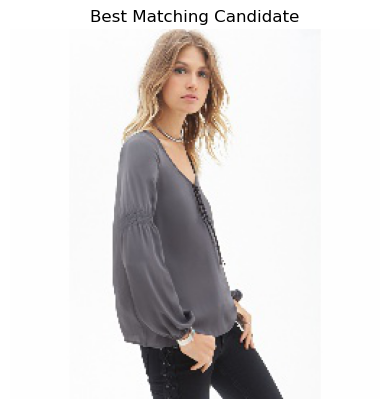

In [32]:
# Load user image and extract keypoints
user_image_path = input("Enter image path: ")  
user_keypoints = extract_keypoints(user_image_path)

if user_keypoints is None:
    raise ValueError("No pose detected in user image.")

#get important keypoints for comparison
important_points = [11, 12, 23, 24]  
best_distance = float('inf')
best_candidate_path = None

#limit candidates to 100 by randomly selecting images
candidate_paths = candidates_df['image_path'].tolist()
random.shuffle(candidate_paths)
candidate_paths = candidate_paths[:100] 

#go through each candidate path and evaluate
for idx, relative_path in enumerate(candidate_paths):
    full_path = os.path.join(base_dir, relative_path)
    candidate_keypoints = extract_keypoints(full_path)

    if candidate_keypoints is None:
        print(f"Skipping {relative_path}: No keypoints detected.")
        continue

    distance = pose_similarity(user_keypoints, candidate_keypoints, important_points)
    print(f"[{idx+1}] Checked {relative_path} | Pose Distance: {distance:.2f}")

    if distance < best_distance:
        best_distance = distance
        best_candidate_path = full_path

# Final check
if best_candidate_path is None:
    raise ValueError("No match found.")
else:
    print(f'Best match: {best_candidate_path}')
    print(f'Best pose similarity distance: {best_distance:.2f}')
    best_image = Image.open(best_candidate_path)
    plt.imshow(best_image)
    plt.axis('off')
    plt.title("Best Matching Candidate")
    plt.show()


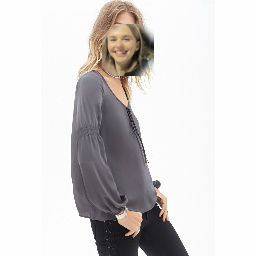

In [36]:
# Initialize MediaPipe Face Detection
mp_face = mp.solutions.face_detection.FaceDetection(
    model_selection=0, min_detection_confidence=0.3
)

# Load the user's head image
head_img = Image.open(user_image_path)
head_img = ImageOps.exif_transpose(head_img).convert("RGB")

# Make sure base image is RGBA for transparency
base_img = best_image.convert("RGBA")
base_img_rgb = best_image.convert("RGB")

# Run MediaPipe face detection on user's head image
np_head = np.array(head_img)
user_results = mp_face.process(np_head)

if not user_results.detections:
    raise ValueError("No face detected in user image! Please use a clearer or more front-facing photo.")

d_user = user_results.detections[0].location_data.relative_bounding_box
h_user, w_user, _ = np_head.shape
ux0, uy0 = int(d_user.xmin * w_user), int(d_user.ymin * h_user)
ux1 = ux0 + int(d_user.width * w_user)
uy1 = uy0 + int(d_user.height * h_user)
head_crop = head_img.crop((ux0, uy0, ux1, uy1))

# Run MediaPipe face detection on base image (RGB version)
np_base = np.array(base_img_rgb)
base_results = mp_face.process(np_base)


if not base_results.detections:
    print("No face detected in base image.")
    raise ValueError("Cannot proceed without a detected head in base image.")

d_base = base_results.detections[0].location_data.relative_bounding_box
h_base, w_base, _ = np_base.shape
bx0, by0 = int(d_base.xmin * w_base), int(d_base.ymin * h_base)
b_width = int(d_base.width * w_base)
b_height = int(d_base.height * h_base)

# You can optionally apply a scale factor if needed
scale_factor = 1.5
new_w = int(b_width * scale_factor)
new_h = int(b_height * scale_factor)
head_rs = head_crop.resize((new_w, new_h), Image.BILINEAR)

# Apply slight offset if needed
x_offset = 0  
y_offset = 0  

# Final position
X = bx0 + x_offset
Y = by0 + y_offset

# Composite
comp = base_img.copy()
head_blended = apply_soft_mask(head_rs) #this function helps a lot to make the overlay more natural
comp.paste(head_blended, (X, Y), head_blended)

display(comp)